# 03 — Что на самом деле двигает спрос

Ноутбуки 01 и 02 установили факты: три всплеска продаж, реальный маркетинговый календарь,
восстановленную удалённую акцию. Здесь мы задаём следующий вопрос — **почему** эти всплески
случились, и что из этого следует для бюджета.

Структура разбора:

1. развести три всплеска по механизму — у них разная природа;
2. показать, что третий не объясняется ни охватом, ни ценой;
3. предъявить внешний фактор, который его объясняет;
4. честно перечислить, что из этого доказано, а что остаётся гипотезой;
5. спроектировать эксперимент, который гипотезу проверит (задача 7);
6. ответить на вопрос про 300 000 ₽ как на правило принятия решения.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 200)
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

ROOT = next(p for p in [Path(".."), Path(".")] if (p / "outputs").exists())
OUT, DATA = ROOT / "outputs", ROOT / "data"

orders = pd.read_csv(OUT / "orders.csv", parse_dates=["ts"])
items = pd.read_csv(OUT / "order_items.csv", parse_dates=["ts"])
posts = pd.read_csv(DATA / "posts.csv", parse_dates=["date"])
items["d"] = items.ts.dt.normalize()

print(f"заказов {len(orders)}, позиций {len(items)}, постов {len(posts)}")

заказов 625, позиций 795, постов 58


## 1. Продуктовые линейки

Каталог делится на несколько линеек, и дальше почти всё будет считаться в этом разрезе.
СТАРТ — начальный уровень, ПРО — продвинутые карьерные курсы с разборами отборов в бигтех
и гарантией оффера, AI агенты — отдельное новое направление.

In [2]:
def line(course: str) -> str:
    c = course.lower()
    if "про" in c:
        return "ПРО"
    if "старт" in c:
        return "СТАРТ"
    if "агент" in c:
        return "AI агенты"
    return "прочее"


items["line"] = items.course.map(line)
print(items.groupby("line").agg(курсов=("course", "nunique"),
                                позиций=("course", "size"),
                                выручка=("amount", "sum")).round(0).to_string())

           курсов  позиций    выручка
line                                 
AI агенты       1       91   711673.0
ПРО             4      273  2162803.0
СТАРТ           4      298  1958143.0
прочее          9      133  1072052.0


## 2. Три всплеска — три механизма

Сводим то, что установлено в ноутбуках 01 и 02, в одну таблицу. Это ключевой слайд всей работы:
одинаковые на графике пики имеют совершенно разную природу, и лечатся они разными решениями.

In [3]:
SPIKES = {
    "08–10.08": ("2026-08-08", "2026-08-10"),
    "22–24.08": ("2026-08-22", "2026-08-24"),
    "04–06.09": ("2026-09-04", "2026-09-06"),
}

daily = (orders.assign(d=orders.ts.dt.normalize())
         .groupby("d").agg(orders=("order_id", "size"), revenue=("revenue", "sum")))
daily = daily[daily.index < daily.index.max()]      # 10.09 обрезан

mk = posts[posts.post_type.isin(["DISCOUNT", "LAUNCH", "SALE"])]

rows = []
for name, (a, b) in SPIKES.items():
    w = daily.loc[a:b]
    win_posts = mk[(mk.date >= a) & (mk.date <= b)]
    rows.append({
        "окно": name,
        "заказов": int(w.orders.sum()),
        "выручка": w.revenue.sum(),
        "медианный охват поста": posts[(posts.date >= a) & (posts.date <= b)].views.median(),
        "маркетинговых постов": len(win_posts),
    })

summary = pd.DataFrame(rows).set_index("окно")
summary["фон, заказов/день"] = round(daily.orders.median(), 1)
summary.round(0)

,заказов,выручка,медианный охват поста,маркетинговых постов,"фон, заказов/день"
окно,,,,,
08–10.08,132,1004697.0,18200.0,3,12.0
22–24.08,84,829718.0,20200.0,1,12.0
04–06.09,119,1150344.0,13900.0,1,12.0


| Окно | Что произошло | Чем подтверждено |
|---|---|---|
| **08–10.08** | распродажа СТАРТ с закрытием набора + выход четырёх новых курсов + 9 внешних упоминаний | падение медианных цен в продажах; посты 1837, 1838, 1840; реестр размещений |
| **22–24.08** | запуск линейки ПРО и курса AI агенты | первая продажа AI агенты 22.08; пост 1859 — самый охватный за период |
| **04–06.09** | ??? ни скидки по ценам, ни запуска, охват средний | — |

Первые два объяснены. Третий — нет, и именно он самый интересный, потому что дал максимум продаж
за весь период.

## 3. Третий всплеск: ни охват, ни цена

Проверяем два очевидных объяснения и отбрасываем оба.

In [4]:
a, b = SPIKES["04–06.09"]
sep_posts = posts[(posts.date >= "2026-09-01") & posts.views.notna()]
aug_posts = posts[(posts.date < "2026-09-01") & posts.views.notna()]

print("ОХВАТ")
print(f"  средний охват поста в августе:  {aug_posts.views.mean():>8,.0f}".replace(",", " "))
print(f"  средний охват поста в сентябре: {sep_posts.views.mean():>8,.0f}".replace(",", " "))
print(f"  охват поста-триггера 1879:      {posts.loc[posts.post_id == 1879, 'views'].iloc[0]:>8,.0f}"
      .replace(",", " "))
print("  -> охват поста ровно на уровне сентябрьской нормы, аномалии нет")

print("\nЦЕНА")
raw = pd.read_excel(DATA / "base.xlsx")
print(f"  якорная цена 14 795 ₽ встречается в данных: {(raw['Сумма'] == 14795).sum()} раз")
print(f"  цена 8 950 ₽ встречается: {(raw['Сумма'] == 8950).sum()} раз — самое частое значение")
print("  -> по медианной цене скидки не видно: 'скидочная' цена и есть обычная")

ОХВАТ
  средний охват поста в августе:    20 649
  средний охват поста в сентябре:   13 354
  охват поста-триггера 1879:        15 300
  -> охват поста ровно на уровне сентябрьской нормы, аномалии нет

ЦЕНА


  якорная цена 14 795 ₽ встречается в данных: 0 раз
  цена 8 950 ₽ встречается: 149 раз — самое частое значение
  -> по медианной цене скидки не видно: 'скидочная' цена и есть обычная


Оба объяснения не проходят. Пост-триггер собрал 15 300 просмотров при сентябрьской норме
около 13 000 — то есть его увидело обычное количество людей. Цена тоже обычная: 8 950 ₽ это
самое частое значение за весь период, а якорные 14 795 ₽ не встречаются ни разу.

Значит дело не в том, **скольким** показали и не в том, **за сколько** продавали.

## 4. Что изменилось: сместилась линейка

Смотрим не на объём, а на структуру продаж.

In [5]:
weekly = (items.assign(w=items.d.dt.to_period("W"))
          .pivot_table(index="w", columns="line", values="amount", aggfunc="sum")
          .fillna(0))
print("выручка по линейкам, по неделям:")
print(weekly.round(0).to_string())

print("\nдоля линейки в выручке:")
for name, mask in [("12–31 августа", (items.d >= "2026-08-12") & (items.d < "2026-09-01")),
                   ("сентябрь",      items.d >= "2026-09-01")]:
    part = items[mask]
    sh = part.groupby("line").amount.sum() / part.amount.sum() * 100
    print(f"  {name:14s} " + "  ".join(f"{k} {v:.0f}%" for k, v in sh.items()))

выручка по линейкам, по неделям:
line                   AI агенты        ПРО     СТАРТ    прочее
w                                                              
2026-08-03/2026-08-09        0.0    93035.0  698657.0  276095.0
2026-08-10/2026-08-16        0.0    70190.0  364185.0  223405.0
2026-08-17/2026-08-23   159250.0   352840.0  225710.0  139250.0
2026-08-24/2026-08-30   273128.0   316648.0  197475.0   92038.0
2026-08-31/2026-09-06   201145.0  1161840.0  416816.0  201290.0
2026-09-07/2026-09-13    78150.0   168250.0   55300.0  139975.0

доля линейки в выручке:
  12–31 августа  AI агенты 20%  ПРО 35%  СТАРТ 28%  прочее 16%
  сентябрь       AI агенты 11%  ПРО 55%  СТАРТ 19%  прочее 15%


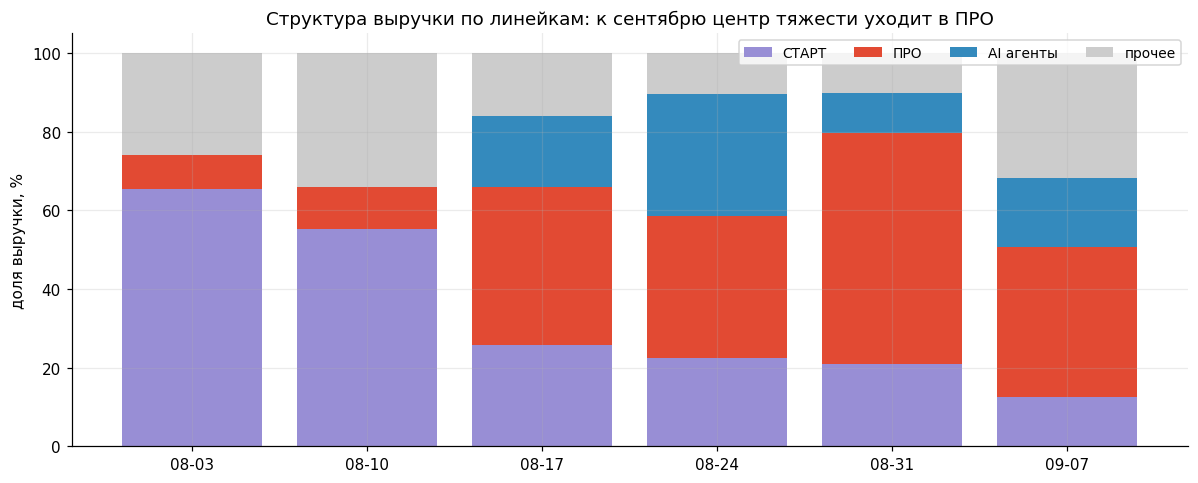

In [6]:
fig, ax = plt.subplots(figsize=(11, 4.5))
share = weekly.div(weekly.sum(axis=1), axis=0) * 100
bottom = np.zeros(len(share))
for col, color in zip(["СТАРТ", "ПРО", "AI агенты", "прочее"],
                      ["#988ED5", "#E24A33", "#348ABD", "#cccccc"]):
    if col in share:
        ax.bar(range(len(share)), share[col], bottom=bottom, label=col, color=color)
        bottom += share[col].values
ax.set_xticks(range(len(share)))
ax.set_xticklabels([str(w).split("/")[0][5:] for w in share.index], rotation=0)
ax.set_ylabel("доля выручки, %")
ax.set_title("Структура выручки по линейкам: к сентябрю центр тяжести уходит в ПРО")
ax.legend(ncol=4, fontsize=9)
plt.tight_layout()
plt.show()

Вот оно. Линейка ПРО вырастает с 35% выручки во второй половине августа до 55% в сентябре,
а неделя 31.08–06.09 даёт по ПРО 1.16 млн ₽ — втрое больше любой предыдущей недели.

Третий всплеск — это не общий рост спроса, это **продажа одной конкретной линейки**.

## 5. Внешний фактор

Чем ПРО отличается от СТАРТ: разборами реальных отборов в бигтех и гарантией оффера.
Креатив поста-триггера прямо перечисляет «Разбор Т-банка», «Разбор Яндекса», «Гарантия оффера»,
а в тексте сказано, что разбор Т-банка уже выложен участникам курсов.

И главное — дедлайн акции. Он не круглый и не случайный.

**Приём заявок на стажировку аналитиком в Т-Банке закрывался 6 сентября включительно.**
Акция «цена до 06.09» заканчивалась в тот же день.

То есть промо было привязано не к своему календарю, а к чужому — к дедлайну найма
в крупной компании. Продукт продавался не сам по себе, а как инструмент, нужный к конкретной
дате.

In [7]:
after = daily.loc["2026-09-07":]
before = daily.loc["2026-09-04":"2026-09-06"]
print("заказов в день:")
print(f"  04–06.09 (до дедлайна):  {before.orders.mean():.1f}")
print(f"  07–09.09 (после):        {after.orders.mean():.1f}")
print(f"  падение:                 {(1 - after.orders.mean() / before.orders.mean()):.0%}")

заказов в день:
  04–06.09 (до дедлайна):  39.7
  07–09.09 (после):        13.0
  падение:                 67%


После 6 сентября продажи падают резко. Это согласуется с механикой дедлайна: спрос
не исчез и не насытился, он был **стянут к дате**. Тот же профиль виден в августе вокруг
закрытия распродажи СТАРТ.

## 6. Что доказано, а что нет

Разделение, на котором стоит вся работа. Не смешивать эти три уровня — главное требование
организаторов.

**Установлено данными:**

- третий всплеск состоит преимущественно из продаж линейки ПРО;
- в ту же неделю выросли и несвязанные линейки — примерно на 115% по двум независимым
  контролям, то есть значительная часть подъёма общая для всего каталога;
- пост-триггер имел обычный охват и обычную цену;
- дедлайн акции совпадает с дедлайном подачи заявок на стажировку в Т-Банке;
- после дедлайна продажи падают.

**Гипотеза (правдоподобная, но не доказанная):**

> спрос на курсы ПРО управляется календарём отбора в бигтех, а акция с дедлайном лишь
> собирает его в точке, которую задаёт внешний работодатель.

**Почему это пока гипотеза, а не вывод:**

1. **Одно наблюдение.** Совпадение дат зафиксировано один раз. Одно совпадение — не закономерность.
2. **Три фактора склеены.** В окне одновременно: дедлайн акции, дедлайн Т-Банка и старт курсов
   07.09. Разделить их вклад при одном наблюдении невозможно.
3. **Сезонность правдоподобна, но не измерена.** Общий подъём около 115% виден по контрольным
   линейкам и, скорее всего, объясняется началом учебного года. Но истории до 4 августа нет,
   сравнить сентябрь с прошлым сентябрём невозможно — это оценка, а не измерение.
4. **Attribution ≠ incrementality.** Даже если бы мы приписали всю выручку посту, это не ответ
   на вопрос, появилась бы она без него.

## 7. Как это проверить (задача 7)

Наблюдательными данными гипотезу не закрыть — нужен дизайн. Ограничение кейса: канал один,
географического или аудиторного сплита в Telegram нет, holdout по подписчикам сделать нельзя.
Значит работают дизайны, опирающиеся на время и на сравнение продуктов.

### 7.1. Difference-in-differences на линейках

Идея: ПРО — «обработанная» группа (привязана к отбору в бигтех), СТАРТ — контрольная
(к отбору не привязана). Если внешний дедлайн действительно двигает спрос, ПРО должна вырасти
относительно СТАРТ сильнее, чем объясняется общим сезонным подъёмом.

Ниже — расчёт на имеющихся данных. Это **иллюстрация метода**, а не доказательство: одно
событие, короткие ряды, контроль несовершенный.

In [8]:
pre  = items[(items.d >= "2026-08-24") & (items.d <= "2026-08-30")]
post = items[(items.d >= "2026-08-31") & (items.d <= "2026-09-06")]

did = pd.DataFrame({
    "до (24–30.08)":  pre.groupby("line").amount.sum(),
    "после (31.08–06.09)": post.groupby("line").amount.sum(),
}).fillna(0)
did["рост, %"] = (did.iloc[:, 1] / did.iloc[:, 0] * 100 - 100).round(0)
print(did.round(0).to_string())

treat, control = did.loc["ПРО", "рост, %"], did.loc["СТАРТ", "рост, %"]
print(f"\nрост ПРО:   {treat:+.0f}%")
print(f"рост СТАРТ: {control:+.0f}%")
print(f"DiD-оценка (разница в темпах): {treat - control:+.0f} п.п.")

           до (24–30.08)  после (31.08–06.09)  рост, %
line                                                  
AI агенты       273128.0             201145.0    -26.0
ПРО             316648.0            1161840.0    267.0
СТАРТ           197475.0             416816.0    111.0
прочее           92038.0             201290.0    119.0

рост ПРО:   +267%
рост СТАРТ: +111%
DiD-оценка (разница в темпах): +156 п.п.


Разница в темпах роста велика, но интерпретировать её как причинный эффект нельзя:
в том же окне ПРО получила акцию, а СТАРТ нет. Контрольная группа «загрязнена» —
это ровно та ошибка, которую задача 7 и просит не делать.

Чтобы DiD стал валидным, нужен следующий цикл отбора **без акции** на ПРО.

### 7.1.1. Разложение роста: сколько в нём сезонности

Рост ПРО на 267% — это не эффект акции. Это сумма двух вещей: общего подъёма, который затронул
всё, и добавки, специфичной для ПРО. DiD как раз и разделяет их, принимая рост контрольной
группы за оценку общего фона.

Ключевая проверка — взять **два независимых контроля** и посмотреть, сходятся ли они.

In [9]:
wk = (items.assign(w=items.d.dt.to_period("W"))
      .pivot_table(index="w", columns="line", values="amount", aggfunc="sum").fillna(0))

pre_w, post_w = wk.index[-3], wk.index[-2]      # 24-30.08 и 31.08-06.09
growth = (wk.loc[post_w] / wk.loc[pre_w] * 100 - 100).round(0)

print(f"рост выручки {pre_w} -> {post_w}:")
print()
for k, v in growth.items():
    print(f"  {k:10s} {v:+.0f}%")

common = growth[["СТАРТ", "прочее"]].mean()
print()
print(f"общий фон по двум контролям: {common:+.0f}%")
print(f"надбавка ПРО сверх фона:     {growth['ПРО'] - common:+.0f} п.п.")

рост выручки 2026-08-24/2026-08-30 -> 2026-08-31/2026-09-06:

  AI агенты  -26%
  ПРО        +267%
  СТАРТ      +111%
  прочее     +119%

общий фон по двум контролям: +115%
надбавка ПРО сверх фона:     +152 п.п.


Два контроля, никак не связанные друг с другом — линейка СТАРТ и девять разрозненных курсов
из категории «прочее» — дают почти одинаковый рост: +111% и +119%. Совпадение двух независимых
оценок это сильный довод в пользу того, что в первую неделю сентября подействовал **общий
фактор**, а не что-то специфичное для одной линейки.

Разложение получается такое:

- общий подъём: около **+115%**, им объясняется большая часть роста;
- надбавка ПРО сверх фона: около **+152 п.п.** — это то, что может быть эффектом акции
  и привязки к дедлайну отбора.

Самое правдоподобное содержание общего фактора — начало учебного года: после лета люди
возвращаются к планам на карьеру, и спрос растёт по всему каталогу сразу.

### 7.1.2. Почему это оценка, а не измерение

Три ограничения, которые надо назвать самим, не дожидаясь вопроса.

**Предпосылка параллельных трендов нарушена.** DiD валиден, когда до события группы двигались
одинаково. Смотрим недельные темпы в pre-периоде.

In [10]:
print("недельные темпы роста, %:")
print()
print((wk.pct_change() * 100).round(0).to_string())

недельные темпы роста, %:

line                   AI агенты    ПРО  СТАРТ  прочее
w                                                     
2026-08-03/2026-08-09        NaN    NaN    NaN     NaN
2026-08-10/2026-08-16        NaN  -25.0  -48.0   -19.0
2026-08-17/2026-08-23        inf  403.0  -38.0   -38.0
2026-08-24/2026-08-30       72.0  -10.0  -13.0   -34.0
2026-08-31/2026-09-06      -26.0  267.0  111.0   119.0
2026-09-07/2026-09-13      -61.0  -86.0  -87.0   -30.0


СТАРТ и «прочее» в августе устойчиво падали, а ПРО в неделю запуска подскочила на +403%.
Линии не параллельны даже близко. Значит **DiD-оценка здесь описательная, а не причинная**:
она показывает, насколько ПРО обогнала фон, но не доказывает, что обогнала из-за акции.

**Контроль загрязнён.** СТАРТ в августе прошла через собственную распродажу с закрытием набора.
Такая акция вытягивает спрос вперёд, после чего идёт провал — что и видно в темпах. База для
сравнения занижена, и рост +111% частично просто отскок.

**Сезонность нечем измерить.** В данных нет истории до 4 августа, а значит нет ни одного
предыдущего сентября. Сравнить сентябрь с сентябрём невозможно. Поэтому корректная формулировка
не «сезонный эффект составил +115%», а:

> в первую неделю сентября выручка выросла примерно на 115% одновременно по нескольким
> несвязанным продуктовым линейкам; наиболее правдоподобное объяснение — начало учебного
> года, но проверить его на имеющихся данных нельзя

Разница между этими двумя фразами и есть разница между «мы оцениваем» и «мы знаем».

**Последняя неделя обрезана.** Провал 07–13.09 в таблице темпов преувеличен: данные
заканчиваются 10 сентября, неделя неполная, для выводов не годится.

### 7.1.3. Что закрыло бы вопрос

- **история за прошлый год** — сезонность измеряется напрямую сравнением сентябрей;
- **следующий цикл отбора без акции на ПРО** — СТАРТ становится чистым контролем,
  и DiD превращается в причинную оценку;
- **randomized promotion** — не требует ни того, ни другого.

### 7.2. Randomized promotion на следующем цикле

Самый чистый из доступных вариантов. Механика:

1. перед следующим окном отбора в бигтех разбиваем аудиторию бота на две случайные группы
   по хешу `user_id`;
2. группа A получает напоминание о дедлайне, группа B — нет;
3. сравниваем конверсию в покупку между группами.

Разница и есть incremental-эффект напоминания. Это требует бота — без него аудиторию
не разделить, потому что пост в канале видят все.

### 7.3. Interrupted time series как минимальный вариант

Если эксперимент поставить не успевают: строим baseline по дням до события с контролем
дня недели, прогнозируем контрфактическую траекторию на окно события, считаем разницу.
Слабее DiD, потому что опирается на предположение о неизменности тренда, но применимо
к уже случившимся всплескам и не требует ничего, кроме имеющихся данных.

### 7.4. Что делает выводы валидными

- окно события фиксируется **до** его наступления, а не подбирается по результату;
- день недели входит в модель: у канала выходные систематически выше будней;
- повторные покупки исключаются из оценки привлечения;
- результат публикуется вместе с доверительным интервалом, а не одним числом.

## 7.5. Что сильнее: новый продукт или привязка к найму

Два всплеска из трёх — это две разные стратегии. 22 августа запускали новое направление,
5 сентября продавали доступ к разбору отбора в Т-Банк с дедлайном. Сравним их прямо.

In [11]:
windows = {"22–24.08 (запуск)": ("2026-08-22", "2026-08-24"),
           "04–06.09 (дедлайн)": ("2026-09-04", "2026-09-06")}

for name, (a, b) in windows.items():
    w = items[(items.d >= a) & (items.d <= b)]
    total = w.amount.sum()
    pro = w.loc[w.line == "ПРО", "amount"].sum()
    print(f"{name}: всего {total:>10,.0f} ₽, из них ПРО {pro:>9,.0f} ₽".replace(",", " "))

22–24.08 (запуск): всего    829 718 ₽  из них ПРО   394 298 ₽
04–06.09 (дедлайн): всего  1 150 344 ₽  из них ПРО   715 524 ₽


Окно дедлайна дало на 39% больше выручки, а по линейке ПРО — почти вдвое. Коммерческий
крючок сработал сильнее продуктовой новости.

Но абсолютные суммы по линейкам сравнивать нельзя: продукты появились в разное время
и находились в продаже разное число дней. Нормируем.

In [12]:
END = items.d.max() - pd.Timedelta(days=1)      # 10.09 обрезан
per_course = items.groupby("course").agg(выручка=("amount", "sum"),
                                         первая_продажа=("d", "min"))
per_course["дней в продаже"] = (END - per_course.первая_продажа).dt.days + 1
per_course["выручка в день"] = (per_course.выручка / per_course["дней в продаже"]).round(0)

print(per_course.sort_values("выручка в день", ascending=False)
      .head(6)[["выручка", "дней в продаже", "выручка в день"]].round(0).to_string())

                  выручка  дней в продаже  выручка в день
course                                                   
AI агенты        711673.0              19         37456.0
Аналитика про    740942.0              33         22453.0
ML про           715110.0              37         19327.0
Аналитика старт  641616.0              37         17341.0
Алгоритмы старт  529852.0              33         16056.0
ML старт         523278.0              37         14143.0


Поправка на время в продаже переворачивает картину. **AI агенты — первый курс каталога
по выручке в день**, 37 456 ₽ против 22 453 ₽ у следующего. В общей таблице линейка выглядит
самой маленькой только потому, что продавалась 19 дней вместо 33–37.

Значит две стратегии не конкурируют, а дополняют друг друга:

- **новое направление** даёт высокую скорость выручки, но его нельзя запускать часто;
- **привязка к дедлайну найма** даёт пик на существующем продукте и повторяется столько раз,
  сколько бигтех открывает наборы.

Практический вывод: запускать новые направления стоит, а не только эксплуатировать бренды
работодателей — данные не поддерживают версию, что публике интересна только коммерция.

## 7.6. Предложение: партнёрство с работодателем вместо закупки рекламы

Гипотеза, которая напрямую следует из всего разобранного выше, и которая не требует
рекламного бюджета вообще.

**Наблюдение, из которого она растёт.** В креативе линейки ПРО уже заявлена «гарантия оффера»,
а всплеск 4–6 сентября показал, что публика платит именно за близость к трудоустройству.
При этом обещание ничем не обеспечено: разбор чужого отбора — это подготовка, а не доступ.

**Механика.** Соглашение с технологической компанией, у которой нет своей образовательной
программы:

| Сторона | Что даёт | Что получает |
|---|---|---|
| Поступашки | постоянное размещение партнёра в канале на срок соглашения | реальный, а не декларативный выход на собеседование для лучших выпускников |
| Компания-партнёр | гарантированный технический собес для топ-N выпускников курса ПРО | поток предварительно отобранных и подготовленных кандидатов + охват 45 тыс. профильной аудитории |

Расчёт — бартер, денежный расход нулевой. Для компании без академической базы стоимость
одного квалифицированного кандидата обычно выше стоимости рекламного размещения,
поэтому обмен экономически осмыслен для обеих сторон.

**Почему это интереснее закупки рекламы именно здесь.** Анализ показал, что почти вся выручка
приходит из собственного канала и органики, а внешние размещения дают мало. Партнёрство
усиливает не охват, а ценность продукта — то есть работает в том месте, где у бизнеса
действительно есть рычаг.

### Что нужно предусмотреть заранее

Идея не бесплатная в смысле рисков, и их честнее назвать сразу.

1. **Юридически «гарантированный собес» мало кто подпишет.** Реалистичная формулировка —
   попадание в приоритетную воронку или пропуск первого этапа отбора, а не обязательство
   компании.
2. **Нужен объективный рейтинг.** «Топ-30» требует сопоставимой оценки: единые критерии,
   защищённая от списывания проверка, публичные правила. Это инфраструктура, которой сейчас нет,
   и её стоимость — основная статья расходов проекта.
3. **Отбор смещён.** Лучшие 30 выпускников с высокой вероятностью прошли бы отбор и без
   партнёрства. Ценность соглашения для студента поэтому ниже, чем кажется, а измерять эффект
   нужно по всей когорте, а не по трудоустройству топ-30.
4. **Бренд-тяга слабее.** Компания без своей академической базы — обычно не Т-Банк и не Яндекс,
   и как маркетинговый аргумент она сработает слабее. Эффект стоит ожидать меньше сентябрьского.
5. **Конфликт с продажей рекламных мест.** Канал уже размещает чужую рекламу за деньги
   (пост 1834, магистратура РУДН с Wildberries). Постоянное бесплатное размещение партнёра
   занимает инвентарь, у которого есть альтернативная стоимость — её надо посчитать и вычесть
   из выгоды.

### Как это измерить

Соглашение удобно тем, что даёт **чистое событие с известной датой** — анонс партнёрства.
Это редкий случай, когда дизайн эксперимента почти бесплатен:

- **ITS** по дате анонса с контролем дня недели — грубая, но немедленная оценка;
- **DiD**: направление, участвующее в партнёрстве, против остальных направлений ПРО.
  Здесь контроль будет чище, чем в разделе 7.1, потому что акции на обе группы не будет;
- **раскатка по одному направлению** вместо всех сразу — тогда остальные направления
  становятся полноценной контрольной группой, а не заимствованной.

Последний пункт — это и есть главная рекомендация по внедрению: запускать партнёрство
не на всей линейке, а на одном направлении, чтобы эффект можно было измерить, а не угадать.

## 8. Ответ на вопрос про 300 000 ₽

Владелец спрашивает, что делать с бюджетом следующего запуска. Правильный ответ — не название
канала, а процедура. Ниже она в том виде, в каком следует из всей проделанной работы.

### Шаг 0. Признать, где мы сейчас

Почти вся выручка периода не имеет закупочной стоимости: собственный канал, своя сеть каналов,
органика и повторные покупки. Настоящая внешняя закупка — девять размещений, из которых
три оказались собственными каналами. То есть **бизнес почти не покупает рекламу и при этом
не знает, стоит ли начинать**.

### Шаг 1. Сначала измеряемость, потом объём

Первые деньги тратятся не на охват, а на возможность что-либо посчитать:

- заменить `t.me/m/<менеджер>` в постах на `t.me/<bot>?start=<placement_id>` — одно изменение
  в шаблоне, после которого каждое размещение различимо;
- завести реестр размещений с обязательными `publication_time` и `cost`;
- логировать `bot_start`, `conversation_started`, `payment` с общим `user_hash`.

Без этого любая сумма распределяется вслепую, а ROMI остаётся неисчислимым. Стоимость шага —
время разработчика, не рекламный бюджет.

### Шаг 2. Разделить бюджет на три корзины

| Корзина | Доля | Назначение |
|---|---|---|
| Проверенное | ~50% | форматы с известным эффектом: привязка к дедлайнам отбора, акции с ограничением по времени |
| Тестовое | ~30% | новые внешние каналы, по 2–3 размещения на канал, обязательно с уникальным `placement_id` |
| Экспериментальное | ~20% | holdout и randomized promotion — плата за знание, а не за охват |

Доли — предложение, а не расчёт: данных для оптимизации пока нет, и заявлять точные проценты
как оптимум было бы подгонкой.

### Шаг 3. Правило отбора каналов до закупки

Исторических цен у бизнеса нет, но решение принимать можно и без них. Для каждого канала
считается порог: **при каком CPM размещение окупается** при текущей модели атрибуции
(расчёт в ноутбуке 02). Дальше прайс канала сравнивается с порогом — прайс всегда известен
заранее, в отличие от истории закупок.

### Шаг 4. Календарь вместо ставки на канал

Главный практический вывод из этого ноутбука: у спроса есть внешние точки концентрации —
дедлайны отбора в крупные компании. Их расписание публично и известно заранее.

Поэтому вопрос «в какой канал вложить 300 тысяч» стоит переформулировать в «к каким датам
готовить запуск». Составить календарь окон найма на следующий год, планировать запуски
и промо под них, а бюджет размещений концентрировать за 1–2 недели до дедлайнов, а не
размазывать равномерно.

### Шаг 5. Что считать успехом

Не ROMI по атрибуции — он зависит от выбранного окна и модели, и им можно нарисовать
любую цифру. Считать нужно две величины:

- `ROMI_attr` — для распределения бюджета между каналами;
- `ROMI_inc` — из эксперимента, для ответа на вопрос, нужна ли реклама вообще.

Если после первого цикла `ROMI_inc` окажется близким к нулю, честный вывод — что деньги лучше
вложить в продукт и в календарь запусков, а не в закупку. Данных, чтобы отвергнуть эту
возможность, сейчас нет.

## 9. Что нужно начать собирать

Сводка того, чего не хватило именно в этом ноутбуке:

| Что | Зачем | Как получить |
|---|---|---|
| `source` у каждого входящего | связать покупку с публикацией | deep link на бота |
| `cost` и `publication_time` размещения | считать ROMI | реестр, заполняется при закупке |
| календарь внешних дедлайнов найма | планировать запуски | публичные страницы программ стажировок |
| флаг участия в эксперименте | считать incremental-эффект | бот, разбиение по хешу пользователя |
| архив собственных постов | промо удаляются после окончания акции | ежедневный слепок канала |

Последняя строка — отдельный урок этой работы. Пост, объяснивший самый крупный всплеск продаж,
был удалён через двое суток. Если бы мы не восстановили его из архива, третий всплеск так
и остался бы необъяснимым. История живого канала систематически теряет именно маркетинг.

In [13]:
summary_out = summary.copy()
summary_out.to_csv(OUT / "spike_summary.csv")
weekly.to_csv(OUT / "revenue_by_line_weekly.csv")
print("сохранено: spike_summary.csv, revenue_by_line_weekly.csv")

сохранено: spike_summary.csv, revenue_by_line_weekly.csv
